# Conceptos en sismología

## Índice<a id="0-índice"></a>
1. [Magnitud sísmica y momento sísmico](#1-magnitud)
2. [Parámetros elásticos](#2-elastic)
3. [Caída de esfuerzos](#3-esfuerzos)
4. [Energía sísmica](#4-energy)
5. [Parámetros de movimientos fuertes](#5-mov-fuertes)
6. [Ejercicios](#6-ejercicios)


## 1. Magnitud sísmica y momento sísmico <a id="1-magnitud"></a>
La magnitud sísmica es una medida adimensional que permite cuantificar y comparar la energía liberada por diferentes sismos, independientemente de su ubicación o profundidad. Una de las formas más precisas de calcularla es a partir del **momento sísmico** \(M_0\), que describe la energía efectiva liberada durante la ruptura de una falla.

El momento sísmico se calcula como:

$$
M_0 = \mu \cdot A \cdot u
$$

donde:

- \(\mu\) = módulo de rigidez del medio (Pa)  
- \(A\) = área de ruptura de la falla (m²)  
- \(u\) = desplazamiento promedio a lo largo de la falla (m)  

A partir de \(M_0\), se determina la **magnitud de momento** \(M_w\) mediante la relación:

$$
M_w = \frac{2}{3} \left( \log_{10} M_0 - 9.1 \right)
$$

[Volver al índice](#0-índice)


## 2. Parámetros elásticos <a id="2-elastic"></a>

En sismología, las **constantes elásticas de Lamé** (\(\lambda\) y \(\mu\)) describen el comportamiento mecánico del medio frente a la propagación de ondas sísmicas.  
Estas constantes dependen directamente de la **densidad del material** y de las **velocidades de las ondas P y S**, parámetros que pueden obtenerse a partir de modelos globales de la estructura interna de la Tierra.
El modelo AK135F es una versión refinada del modelo AK135, con una corrección denominada *Free surface* (“F”), que mejora la representación de las velocidades cercanas a la superficie.  
Este modelo es ampliamente utilizado en sismología global para el cálculo de **tiempos de viaje**, **propiedades elásticas** y **modelado de la propagación sísmica**.

A partir de los valores de densidad \(\rho\), velocidad de onda compresional (\(V_p\)) y velocidad de onda de cizalla (\(V_s\)) proporcionados por el modelo AK135F, se calculan las constantes de Lamé mediante las siguientes expresiones:

$$
\mu = \rho V_s^2
$$

$$
\lambda = \rho \left( V_p^2 - 2V_s^2 \right)
$$

donde:

$$
\mu : \text{ módulo de rigidez o módulo de corte (Pa)} \\
\lambda : \text{ primera constante de Lamé (Pa)} \\
\rho : \text{ densidad del medio (kg/m³)} \\
V_p : \text{ velocidad de onda P (m/s)} \\
V_s : \text{ velocidad de onda S (m/s)}
$$


In [62]:
import pandas as pd         
import numpy as np          
import matplotlib.pyplot as plt 
from obspy.clients.fdsn import Client
from obspy import read,UTCDateTime
from scipy.optimize import curve_fit
from scipy.signal import tukey

In [17]:
AK135F = pd.read_csv('../Archivos/AK135F_complete.csv')
Dth = AK135F['Depth_km'].values
Rho = AK135F['Density_MgKm3'].values
Pv = AK135F['Vp_km_s'].values
Sv = AK135F['Vs_km_s'].values

Dens = Rho*(1e-6)*(1e9)
Vp = Pv*1000
Vs = Sv*1000
Mu = Dens*(Vs**2)
La = Dens*((Vp**2)-2*(Vs**2))


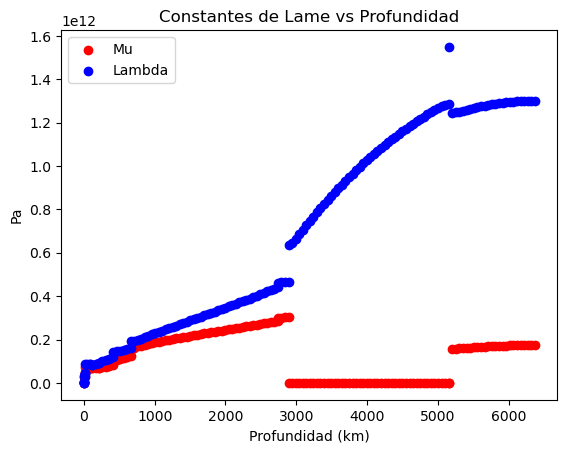

In [18]:
plt.scatter(Dth, Mu, c='red', label='Mu')
plt.scatter(Dth, La, c='blue', label='Lambda')
plt.xlabel('Profundidad (km)')
plt.ylabel('Pa')
plt.title('Constantes de Lame vs Profundidad')
plt.legend()
plt.show()


[Volver al índice](#0-índice)

## 3. Caída de esfuerzos <a id="3-esfuerzos"></a>
La **caída de esfuerzos** $(\Delta \sigma)$ describe la energía liberada durante el sismo:

$$
\Delta \sigma = \sigma_{\text{inicial}} - \sigma_{\text{residual}}
$$


In [31]:
client = Client("IRIS") 

In [32]:
t0 = UTCDateTime("2023-10-04T06:00:00")  
st = client.get_waveforms(network="IU", station="ANMO", location="00", channel="BHZ",
                          starttime=t0, endtime=t0 + 600)

In [46]:
inv = client.get_stations(network="IU", station="ANMO", location="00", channel="BHZ",
                          starttime=t0, endtime=t0+600, level="response")

In [47]:
tr = st[0].copy()
tr.detrend('linear')
tr.taper(max_percentage=0.05, type='cosine')

IU.ANMO.00.BHZ | 2023-10-04T06:00:00.019538Z - 2023-10-04T06:09:59.994538Z | 40.0 Hz, 24000 samples

In [48]:
tr.remove_response(inventory=inv, output="VEL", zero_mean=True, taper=False)
tr.data = np.cumsum(tr.data) * tr.stats.delta 

In [49]:
t_center = tr.stats.starttime + 120  # ajustar
t1 = t_center - 10
t2 = t_center + 50
tr_window = tr.copy().trim(starttime=t1, endtime=t2)
# volver a taper la ventana
win = tukey(len(tr_window.data), alpha=0.1)
tr_window.data = tr_window.data * win

C:\Users\Huawei\AppData\Local\Temp\ipykernel_5476\610523841.py:6: DeprecationWarning: Importing tukey from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.tukey' or the convenience function 'scipy.signal.get_window' instead.
  win = tukey(len(tr_window.data), alpha=0.1)


In [50]:
n = len(tr_window.data)
dt = tr_window.stats.delta
freq = np.fft.rfftfreq(n, d=dt)
spec = np.abs(np.fft.rfft(tr_window.data)) * dt

In [51]:
def brune(f, Omega0, fc):
    return Omega0 / (1.0 + (f/fc)**2)

In [52]:
mask = (freq>0.05) & (freq<20)
f_fit = freq[mask]
y_fit = spec[mask]
p0 = [np.max(y_fit), 2.0]  # inicio: Omega0 y fc
popt, pcov = curve_fit(brune, f_fit, y_fit, p0=p0, maxfev=10000)
Omega0_est, fc_est = popt
Omega0_err, fc_err = np.sqrt(np.diag(pcov))
print("Omega0:", Omega0_est, "+/-", Omega0_err)
print("fc:", fc_est, "+/-", fc_err)

Omega0: 1.2404147617268221e-06 +/- 5.2702584307762604e-08
fc: -0.22410621900552766 +/- 0.01113603342030907


In [53]:
Mo = 1e15  # sustituir por valor correcto
beta = 3500.0
k = 0.37
r = (k * beta) / (2 * np.pi * fc_est)
delta_sigma = (7.0/16.0) * (Mo / r**3)
print("r (m):", r, "Delta_sigma (Pa):", delta_sigma, "Delta_sigma (MPa):", delta_sigma/1e6)


r (m): -919.6784106152842 Delta_sigma (Pa): -562432.0782310838 Delta_sigma (MPa): -0.5624320782310838


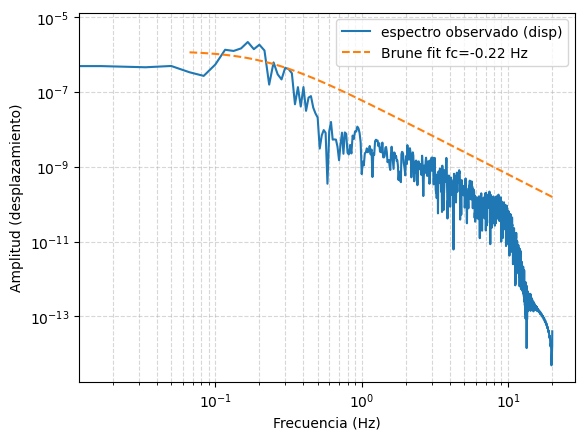

In [55]:
plt.figure()
plt.loglog(freq, spec, label='espectro observado (disp)')
plt.loglog(f_fit, brune(f_fit, *popt), '--', label=f'Brune fit fc={fc_est:.2f} Hz')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud (desplazamiento)')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()
                      

[Volver al índice](#0-índice)

## 4. Energía sísmica  <a id="4-energy"></a>
Se calcula la **energía total** del evento y el **esfuerzo aparente** mediante las siguientes relaciones:

$$
E_T = E_R + E_D
$$

$$
\tau_a = \mu \frac{E_R}{M_0}
$$


donde:


$
E_T \text{ : energía total liberada} \\
E_R \text{ : energía radiada} \\
E_D \text{ : energía disipada} \\
\tau_a \text{ : esfuerzo aparente} \\
\mu \text{ : módulo de rigidez} \\
M_0 \text{ : momento sísmico}
$


In [56]:
rho = 2700.0        # densidad (kg/m^3) ejemplo: roca cortical
beta = 3500.0       # velocidad de corte (m/s)
C = 4.0 * np.pi**2 * rho * beta**3

In [57]:
client = Client("IRIS")
starttime = UTCDateTime("2023-10-04T06:00:00")
endtime   = starttime + 300  # 5 minutos de registro
network, station, location, channel = "IU", "ANMO", "00", "BHZ"

In [58]:
st = client.get_waveforms(network, station, location, channel, starttime, endtime)
inv = client.get_stations(network=network, station=station, location=location, channel=channel,
                          starttime=starttime, endtime=endtime, level="response")

In [59]:
tr = st[0].copy()
tr.detrend('linear')
tr.taper(max_percentage=0.05, type='cosine')

IU.ANMO.00.BHZ | 2023-10-04T06:00:00.019538Z - 2023-10-04T06:04:59.994538Z | 40.0 Hz, 12000 samples

In [60]:
tr.remove_response(inventory=inv, output="VEL", zero_mean=True, taper=False)

IU.ANMO.00.BHZ | 2023-10-04T06:00:00.019538Z - 2023-10-04T06:04:59.994538Z | 40.0 Hz, 12000 samples

In [61]:
tcenter = tr.stats.starttime + 120
tw_start = tcenter - 10
tw_end   = tcenter + 50
tr_win = tr.copy().trim(starttime=tw_start, endtime=tw_end)

[Volver al índice](#0-índice)

## 5. Parámetros de movimientos fuertes  <a id="5-mov-fuertes"></a>
Los parámetros de movimientos fuertes describen los movimientos del suelo provocados por sismos de moderada a gran magnitud que pueden causar daños estructurales. 

A partir de registros sísmicos se calculan variables fundamentales como la aceleración **(PGA)**, la velocidad **(PGV)** y el desplazamiento máximos **(PGD)**. 

In [65]:
client = Client("IRIS")
starttime = UTCDateTime("2023-10-04T06:00:00")
endtime   = starttime + 300  # 5 minutos
network, station, location, channel = "IU", "ANMO", "00", "BHZ"

In [66]:
st = client.get_waveforms(network, station, location, channel, starttime, endtime)
st.detrend("linear")
st.filter("bandpass", freqmin=0.1, freqmax=5)

1 Trace(s) in Stream:
IU.ANMO.00.BHZ | 2023-10-04T06:00:00.019538Z - 2023-10-04T06:04:59.994538Z | 40.0 Hz, 12000 samples

In [67]:
tr = st[0]
data = tr.data * 1e-9  # convertir de nm/s a m/s
dt = tr.stats.delta
time = np.linspace(0, tr.stats.npts*dt, tr.stats.npts)

In [68]:
PGA = np.max(np.abs(data))                     # velocidad máxima (m/s)
PGV = np.trapz(np.abs(data), dx=dt) / len(data)  # promedio integrado (aprox.)
PGD = np.trapz(data, dx=dt) 

In [69]:
print(f"Aceleración máxima (PGA) ≈ {PGA:.2e} m/s")
print(f"Velocidad máxima (PGV) ≈ {PGV:.2e} m/s")
print(f"Desplazamiento máximo (PGD) ≈ {PGD:.2e} m")

Aceleración máxima (PGA) ≈ 1.08e-06 m/s
Velocidad máxima (PGV) ≈ 5.76e-09 m/s
Desplazamiento máximo (PGD) ≈ -5.40e-07 m


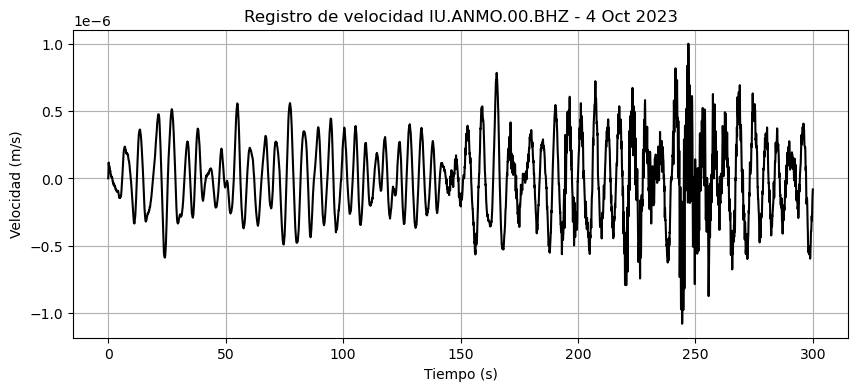

In [70]:
plt.figure(figsize=(10,4))
plt.plot(time, data, color='k')
plt.title("Registro de velocidad IU.ANMO.00.BHZ - 4 Oct 2023")
plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad (m/s)")
plt.grid(True)
plt.show()

[Volver al índice](#0-índice)

## 6. Ejercicios  <a id="6-ejercicios"></a>


1. **Momento sísmico y magnitud**  
   - Crea arrays de ejemplo para módulo de rigidez `mu`, área de falla `A` y desplazamiento `u`.  
   - Escribe funciones para calcular el momento sísmico `M0` y la magnitud de momento `Mw`.

2. **Constantes elásticas**  
   - Crea arrays de ejemplo de densidad `rho` y velocidades `Vp` y `Vs`.  
   - Calcula los arrays de `Mu` y `La` usando las fórmulas de Lamé.  
   - Grafica `Mu` y `La` frente a profundidad `Dth`.

3. **Procesamiento de registro sísmico simulado**  
   - Genera un array `tr_data` de 1000 muestras aleatorias y define `dt`.  
   - Aplica detrend y ventana tipo Tukey.  
   - Calcula el espectro con FFT y grafícalo.

4. **Ajuste de espectro tipo Brune**  
   - Define la función `brune(f, Omega0, fc)` como en la libreta.  
   - Haz un ajuste sobre el espectro calculado usando `curve_fit`.  
   - Grafica el espectro original y el ajuste Brune juntos.

5. **Parámetros de movimientos fuertes**  
   - Calcula PGA, PGV y PGD a partir de `tr_data` y `dt`.  
   - Grafica el registro simulado y marca los valores máximos de PGA, PGV y PGD.



### Referencias

Research School of Earth Sciences, Australian National University. (s. f.). Model ak135-F. Recuperado de: https://rses.anu.edu.au/seismology/ak135/ak135f.html